# Áp dụng Multilayer Perceptron (MLP) để phân loại ung thư trong tập dữ liệu WDBC

## 1. Import và Cài đặt

In [29]:
# Import thư viện chuẩn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# Cài đặt hiển thị
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)

# Tạo thư mục reports nếu chưa có
import os
os.makedirs('../reports', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print("Đã import thành công tất cả thư viện!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Đã import thành công tất cả thư viện!
NumPy version: 2.4.1
Pandas version: 2.3.3


## 2. Bước 1 - Dataset Curation: Load và Khám phá Dữ liệu

**Mục tiêu:**
- Load dữ liệu WDBC từ file CSV
- Loại bỏ cột nhiễu (`id`, `Unnamed: 32`)
- Mã hóa nhãn: M (Malignant) → 0, B (Benign) → 1

In [30]:
# Load dữ liệu
DATA_PATH = '../data/data.csv'
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("THÔNG TIN DATASET GỐC")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nDanh sách cột ({len(df.columns)} cột):")
print(df.columns.tolist())

THÔNG TIN DATASET GỐC
Shape: (569, 33)

Danh sách cột (33 cột):
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


In [31]:
# Xem 5 dòng đầu
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [32]:
# Loại bỏ cột nhiễu
columns_to_drop = ['id']

# Kiểm tra cột rỗng hoặc cột có tên rỗng
for col in df.columns:
    if col == '' or 'Unnamed' in str(col) or df[col].isna().all():
        columns_to_drop.append(col)

print(f"Các cột sẽ loại bỏ: {columns_to_drop}")

df_clean = df.drop(columns=[c for c in columns_to_drop if c in df.columns], errors='ignore')
print(f"Shape sau khi làm sạch: {df_clean.shape}")

Các cột sẽ loại bỏ: ['id', 'Unnamed: 32']
Shape sau khi làm sạch: (569, 31)


In [33]:
# Mã hóa nhãn diagnosis: M → 0 (Malignant), B → 1 (Benign)
LABEL_MAPPING = {'M': 0, 'B': 1}
LABEL_NAMES = ['Malignant (M)', 'Benign (B)']

df_clean['diagnosis'] = df_clean['diagnosis'].map(LABEL_MAPPING)

print("Phân bố nhãn sau mã hóa:")
print(df_clean['diagnosis'].value_counts().sort_index())
print(f"\n0 = Malignant (Ác tính) - Khối u ác tính")
print(f"1 = Benign (Lành tính) - Khối u lành tính")

Phân bố nhãn sau mã hóa:
diagnosis
0    212
1    357
Name: count, dtype: int64

0 = Malignant (Ác tính) - Khối u ác tính
1 = Benign (Lành tính) - Khối u lành tính


### Biểu đồ 1: Phân bố lớp (Class Distribution)

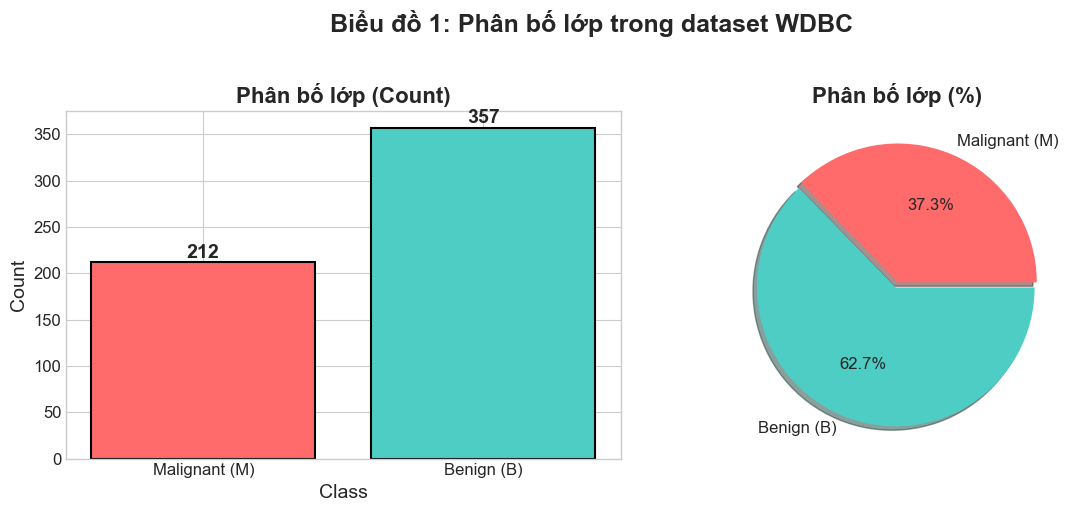

Đã lưu: reports/01_class_distribution.png


In [34]:
# Biểu đồ 1: Phân bố lớp
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_clean['diagnosis'].value_counts().sort_index()
colors = ['#ff6b6b', '#4ecdc4']

# Bar chart
bars = axes[0].bar(LABEL_NAMES, counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Class', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].set_title('Phân bố lớp (Count)', fontsize=16, fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=14, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=LABEL_NAMES, autopct='%1.1f%%',
            colors=colors, explode=[0.02, 0.02], shadow=True,
            textprops={'fontsize': 12})
axes[1].set_title('Phân bố lớp (%)', fontsize=16, fontweight='bold')

plt.suptitle('Biểu đồ 1: Phân bố lớp trong dataset WDBC', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Đã lưu: reports/01_class_distribution.png")

## 3. Bước 2: Trực quan hóa EDA

### Biểu đồ 2: Ma trận tương quan (Correlation Heatmap)

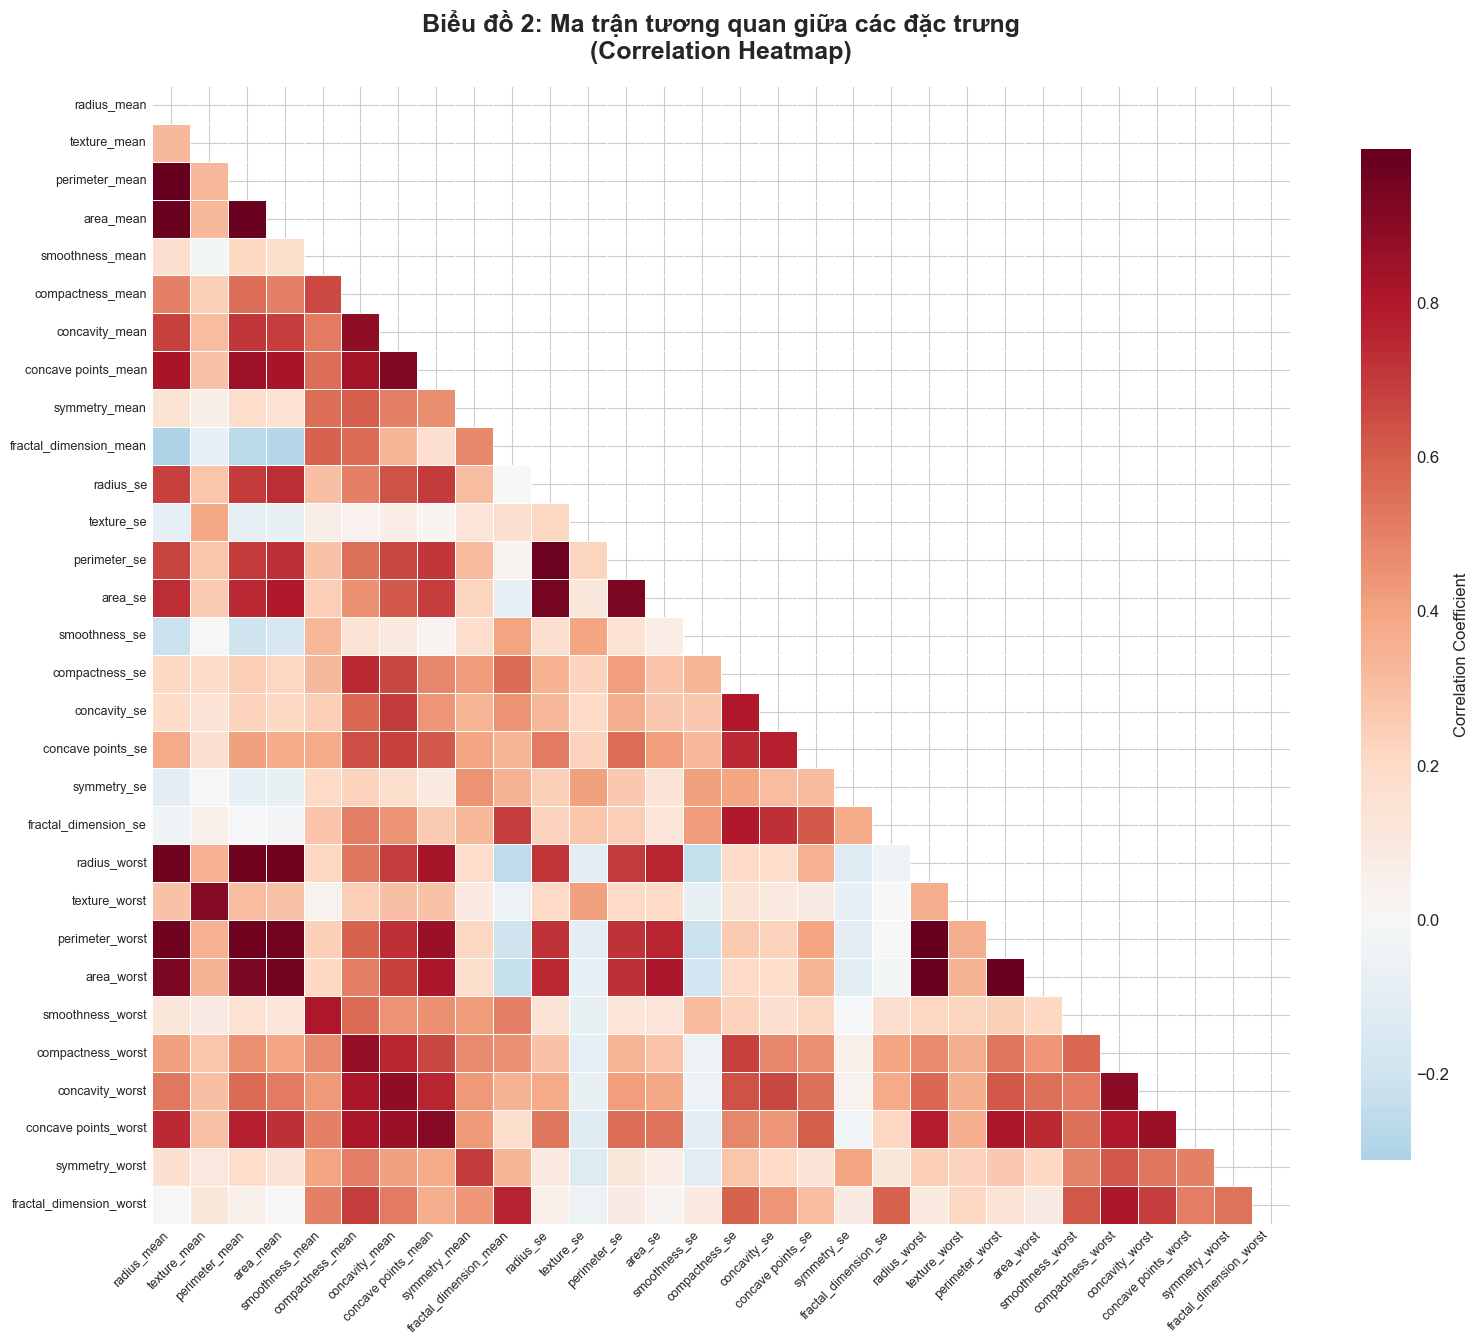

Đã lưu: reports/02_correlation_heatmap.png


In [35]:
# Biểu đồ 2: Correlation Heatmap
X_df = df_clean.drop(columns=['diagnosis'])

fig, ax = plt.subplots(figsize=(16, 14))

corr_matrix = X_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
            ax=ax)

ax.set_title('Biểu đồ 2: Ma trận tương quan giữa các đặc trưng\n(Correlation Heatmap)', 
             fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('../reports/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Đã lưu: reports/02_correlation_heatmap.png")

In [36]:
# Tìm các cặp đặc trưng có tương quan cao (>0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

print("Các cặp đặc trưng có tương quan rất cao (|r| > 0.9):")
print("-" * 60)
for f1, f2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f"{f1} <-> {f2}: {corr:.4f}")

Các cặp đặc trưng có tương quan rất cao (|r| > 0.9):
------------------------------------------------------------
radius_mean <-> perimeter_mean: 0.9979
radius_worst <-> perimeter_worst: 0.9937
radius_mean <-> area_mean: 0.9874
perimeter_mean <-> area_mean: 0.9865
radius_worst <-> area_worst: 0.9840
perimeter_worst <-> area_worst: 0.9776
radius_se <-> perimeter_se: 0.9728
perimeter_mean <-> perimeter_worst: 0.9704
radius_mean <-> radius_worst: 0.9695
perimeter_mean <-> radius_worst: 0.9695


## 4. Bước 3: Tiền xử lý và Chia Train-Test

In [37]:
# Tách features và labels
X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

print("=" * 60)
print("THÔNG TIN DỮ LIỆU")
print("=" * 60)
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Số features: {X.shape[1]}")

THÔNG TIN DỮ LIỆU
Features shape: (569, 30)
Labels shape: (569,)
Số features: 30


In [38]:
# Chia train/test (80% train, 20% test)
RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y
)

print("=" * 60)
print("KẾT QUẢ CHIA TRAIN/TEST")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} mẫu ({100*(1-TEST_SIZE):.0f}%)")
print(f"Test set: {X_test.shape[0]} mẫu ({100*TEST_SIZE:.0f}%)")

KẾT QUẢ CHIA TRAIN/TEST
Training set: 455 mẫu (80%)
Test set: 114 mẫu (20%)


## 5. Bước 4 - Data Normalization: Chuẩn hóa Z-Score

**Công thức Z-Score:**
$$z = \frac{x - \mu}{\sigma}$$

In [39]:
# Chuẩn hóa Z-Score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("CHUẨN HÓA Z-SCORE (StandardScaler)")
print("=" * 60)
print(f"Công thức: z = (x - mean) / std")
print(f"\nSau chuẩn hóa (Training set):")
print(f"  - Mean: {X_train_scaled.mean():.10f} (xấp xỉ 0)")
print(f"  - Std: {X_train_scaled.std():.10f} (xấp xỉ 1)")

CHUẨN HÓA Z-SCORE (StandardScaler)
Công thức: z = (x - mean) / std

Sau chuẩn hóa (Training set):
  - Mean: 0.0000000000 (xấp xỉ 0)
  - Std: 1.0000000000 (xấp xỉ 1)


## 6. Bước 5 - Build Model: SO SÁNH 3 CẤU HÌNH MLP

Để tìm ra cấu hình tối ưu, chúng ta sẽ so sánh 3 mô hình:

| Model | Hidden Layers | Activation | Learning Rate | Mục đích |
|-------|---------------|------------|---------------|----------|
| **Model 1** | (64, 32) | Sigmoid | 0.001 | Baseline - Thể hiện vấn đề Vanishing Gradient |
| **Model 2** | (100,) | Sigmoid | 0.01 | Sigmoid tối ưu - 1 layer, learning rate cao |
| **Model 3** | (64, 32) | ReLU | 0.001 | So sánh activation function |

### Lý thuyết về Vanishing Gradient với Sigmoid

**Sigmoid:** $g(z) = \frac{1}{1+e^{-z}}$

**Đạo hàm Sigmoid:** $g'(z) = g(z)(1-g(z))$, giá trị tối đa = 0.25

Với mạng nhiều layers, gradient bị nhân liên tiếp:
- 2 layers: $0.25 \times 0.25 = 0.0625$ (6.25%)
- 3 layers: $0.25^3 = 0.0156$ (1.56%)

→ Gradient quá nhỏ, weights không được cập nhật đủ → Model không học được.

In [40]:
# Định nghĩa 3 cấu hình model
model_configs = {
    'Model 1: Sigmoid Baseline': {
        'hidden_layer_sizes': (64, 32),
        'activation': 'logistic',  # Sigmoid
        'learning_rate_init': 0.001,
        'max_iter': 500,
        'description': '2 hidden layers, Sigmoid, lr=0.001 (Vanishing Gradient)'
    },
    'Model 2: Sigmoid Optimized': {
        'hidden_layer_sizes': (100,),
        'activation': 'logistic',  # Sigmoid
        'learning_rate_init': 0.01,
        'max_iter': 1000,
        'description': '1 hidden layer, Sigmoid, lr=0.01 (Giảm vanishing gradient)'
    },
    'Model 3: ReLU': {
        'hidden_layer_sizes': (64, 32),
        'activation': 'relu',
        'learning_rate_init': 0.001,
        'max_iter': 500,
        'description': '2 hidden layers, ReLU, lr=0.001 (Không có vanishing gradient)'
    }
}

print("=" * 70)
print("3 CẤU HÌNH MLP SẼ ĐƯỢC SO SÁNH")
print("=" * 70)
for name, config in model_configs.items():
    print(f"\n{name}:")
    print(f"  - Hidden layers: {config['hidden_layer_sizes']}")
    print(f"  - Activation: {config['activation']}")
    print(f"  - Learning rate: {config['learning_rate_init']}")
    print(f"  - Max iterations: {config['max_iter']}")
    print(f"  - Mô tả: {config['description']}")

3 CẤU HÌNH MLP SẼ ĐƯỢC SO SÁNH

Model 1: Sigmoid Baseline:
  - Hidden layers: (64, 32)
  - Activation: logistic
  - Learning rate: 0.001
  - Max iterations: 500
  - Mô tả: 2 hidden layers, Sigmoid, lr=0.001 (Vanishing Gradient)

Model 2: Sigmoid Optimized:
  - Hidden layers: (100,)
  - Activation: logistic
  - Learning rate: 0.01
  - Max iterations: 1000
  - Mô tả: 1 hidden layer, Sigmoid, lr=0.01 (Giảm vanishing gradient)

Model 3: ReLU:
  - Hidden layers: (64, 32)
  - Activation: relu
  - Learning rate: 0.001
  - Max iterations: 500
  - Mô tả: 2 hidden layers, ReLU, lr=0.001 (Không có vanishing gradient)


In [54]:
# Huấn luyện và đánh giá tất cả các models
results = {}
trained_models = {}

for name, config in model_configs.items():
    print("\n" + "=" * 70)
    print(f"TRAINING: {name}")
    print("=" * 70)
    
    # Tạo model
    model = MLPClassifier(
        hidden_layer_sizes=config['hidden_layer_sizes'],
        activation=config['activation'],
        solver='adam',
        learning_rate_init=config['learning_rate_init'],
        max_iter=config['max_iter'],
        random_state=RANDOM_STATE,
        early_stopping=False,  # Tắt early stopping để thấy rõ sự khác biệt
        verbose=False
    )
    
    # Huấn luyện
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time
    
    # Dự đoán
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)
    
    # Tính metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
    roc_auc = auc(fpr, tpr)
    
    # Lưu kết quả
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'train_time': train_time,
        'n_iter': model.n_iter_,
        'final_loss': model.loss_,
        'loss_curve': model.loss_curve_,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'fpr': fpr,
        'tpr': tpr,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    trained_models[name] = model
    
    # In kết quả
    print(f"\nKết quả {name}:")
    print(f"  - Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  - Precision: {precision:.4f}")
    print(f"  - Recall:    {recall:.4f}")
    print(f"  - F1-Score:  {f1:.4f}")
    print(f"  - ROC-AUC:   {roc_auc:.4f}")
    print(f"  - Epochs:    {model.n_iter_}")
    print(f"  - Final Loss: {model.loss_:.6f}")
    print(f"  - Train Time: {train_time:.2f}s")


TRAINING: Model 1: Sigmoid Baseline

Kết quả Model 1: Sigmoid Baseline:
  - Accuracy:  0.9561 (95.61%)
  - Precision: 0.9483
  - Recall:    0.9603
  - F1-Score:  0.9535
  - ROC-AUC:   0.9960
  - Epochs:    278
  - Final Loss: 0.037809
  - Train Time: 0.73s

TRAINING: Model 2: Sigmoid Optimized

Kết quả Model 2: Sigmoid Optimized:
  - Accuracy:  0.9649 (96.49%)
  - Precision: 0.9588
  - Recall:    0.9673
  - F1-Score:  0.9627
  - ROC-AUC:   0.9924
  - Epochs:    228
  - Final Loss: 0.004171
  - Train Time: 0.79s

TRAINING: Model 3: ReLU

Kết quả Model 3: ReLU:
  - Accuracy:  0.9649 (96.49%)
  - Precision: 0.9588
  - Recall:    0.9673
  - F1-Score:  0.9627
  - ROC-AUC:   0.9937
  - Epochs:    164
  - Final Loss: 0.004521
  - Train Time: 0.21s


### Biểu đồ 3: So sánh Learning Curves của 3 Models

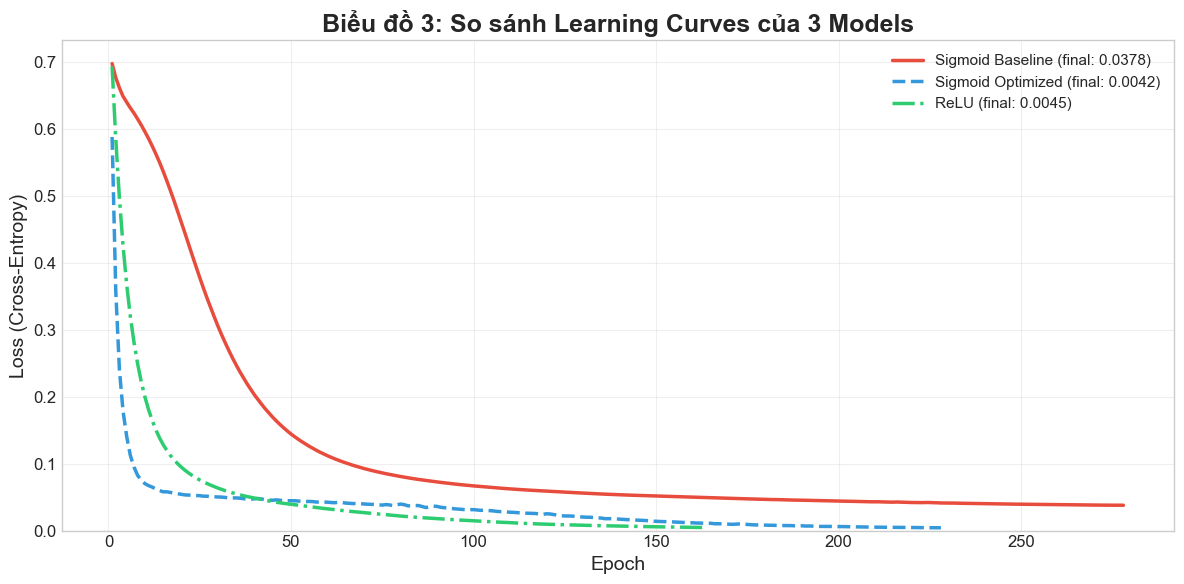

Đã lưu: reports/03_learning_curves_comparison.png


In [42]:
# Biểu đồ 3: So sánh Learning Curves
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#e74c3c', '#3498db', '#2ecc71']
linestyles = ['-', '--', '-.']

for i, (name, res) in enumerate(results.items()):
    loss_curve = res['loss_curve']
    epochs = range(1, len(loss_curve) + 1)
    short_name = name.split(': ')[1]  # Lấy tên ngắn
    ax.plot(epochs, loss_curve, color=colors[i], linewidth=2.5, 
            linestyle=linestyles[i], label=f"{short_name} (final: {loss_curve[-1]:.4f})")

ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('Loss (Cross-Entropy)', fontsize=14)
ax.set_title('Biểu đồ 3: So sánh Learning Curves của 3 Models', 
             fontsize=18, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../reports/03_learning_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Đã lưu: reports/03_learning_curves_comparison.png")

### Biểu đồ 4: So sánh Accuracy của 3 Models

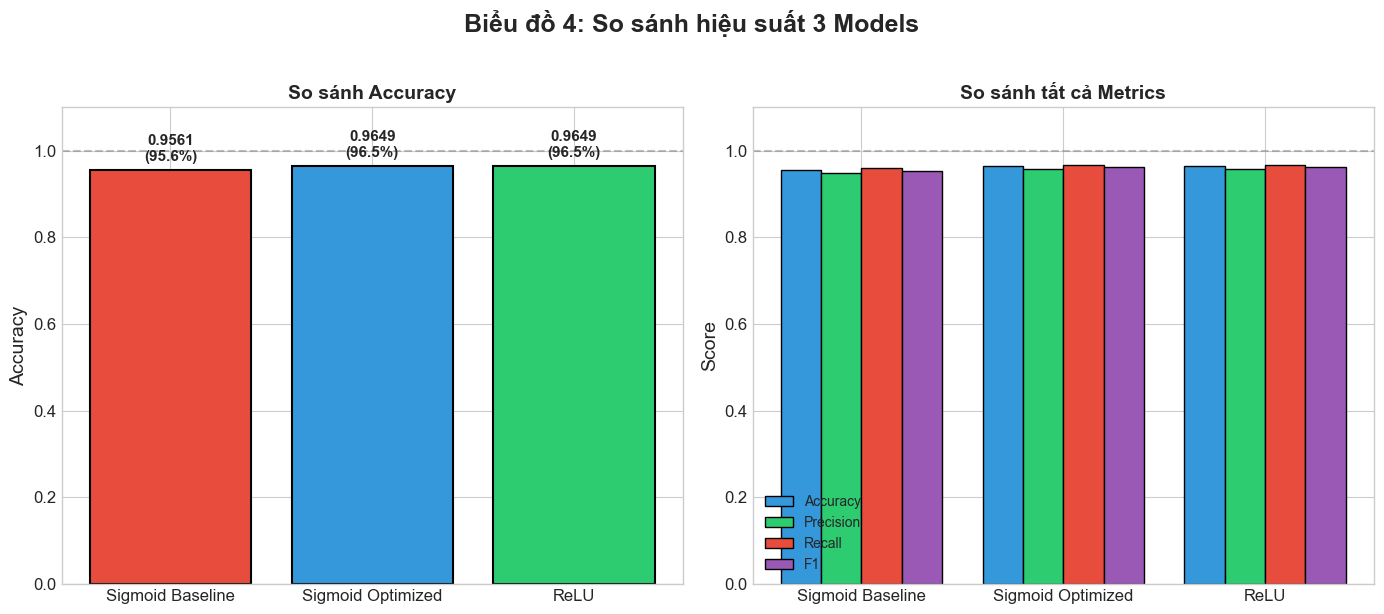

Đã lưu: reports/04_metrics_comparison.png


In [43]:
# Biểu đồ 4: So sánh Accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_names = [name.split(': ')[1] for name in results.keys()]
accuracies = [res['accuracy'] for res in results.values()]
colors = ['#e74c3c', '#3498db', '#2ecc71']

# Bar chart - Accuracy
bars = axes[0].bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Accuracy', fontsize=14)
axes[0].set_title('So sánh Accuracy', fontsize=14, fontweight='bold')
axes[0].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{acc:.4f}\n({acc*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')

# Bar chart - All metrics
x = np.arange(len(model_names))
width = 0.2

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
metric_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, metric in enumerate(metrics_to_plot):
    values = [res[metric] for res in results.values()]
    axes[1].bar(x + i*width, values, width, label=metric.capitalize(), 
                color=metric_colors[i], edgecolor='black')

axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(model_names)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score', fontsize=14)
axes[1].set_title('So sánh tất cả Metrics', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Biểu đồ 4: So sánh hiệu suất 3 Models', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/04_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Đã lưu: reports/04_metrics_comparison.png")

### Biểu đồ 5: Confusion Matrix của 3 Models

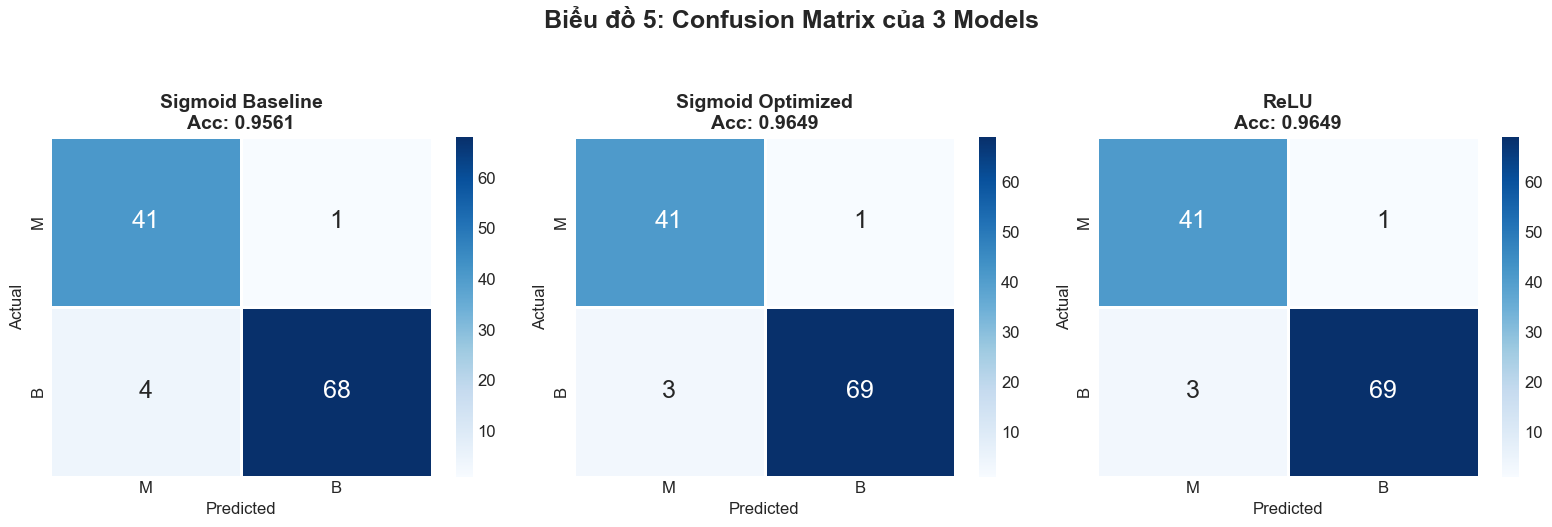

Đã lưu: reports/05_confusion_matrices.png


In [44]:
# Biểu đồ 5: Confusion Matrix cho cả 3 models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, res) in enumerate(results.items()):
    cm = res['confusion_matrix']
    short_name = name.split(': ')[1]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['M', 'B'], yticklabels=['M', 'B'],
                annot_kws={'size': 18}, ax=axes[idx],
                linewidths=2, linecolor='white')
    
    axes[idx].set_xlabel('Predicted', fontsize=12)
    axes[idx].set_ylabel('Actual', fontsize=12)
    axes[idx].set_title(f'{short_name}\nAcc: {res["accuracy"]:.4f}', 
                        fontsize=14, fontweight='bold')

plt.suptitle('Biểu đồ 5: Confusion Matrix của 3 Models', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('../reports/05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("Đã lưu: reports/05_confusion_matrices.png")

### Biểu đồ 6: ROC Curves của 3 Models

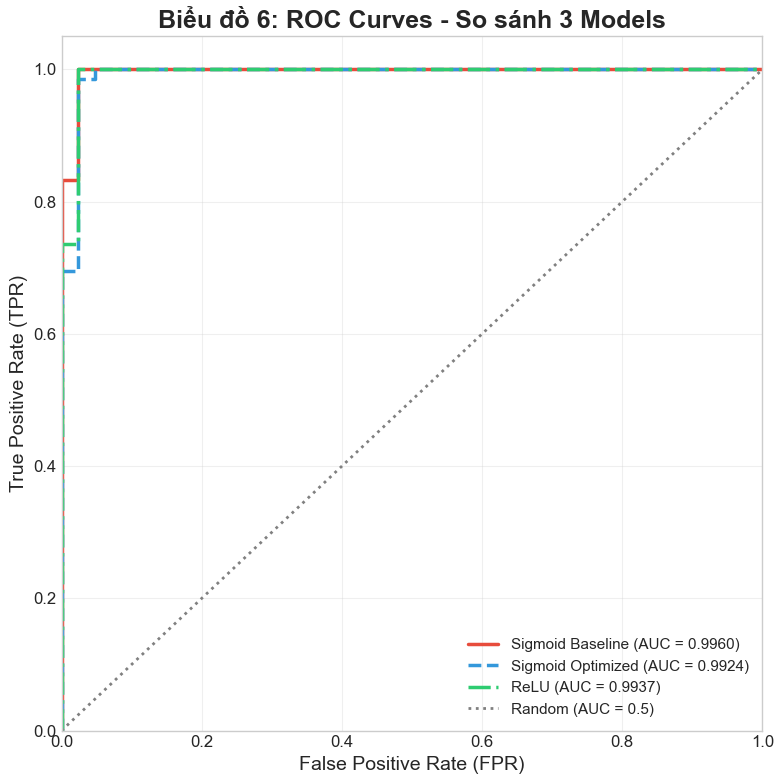

Đã lưu: reports/06_roc_curves.png


In [45]:
# Biểu đồ 6: ROC Curves
fig, ax = plt.subplots(figsize=(8, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71']
linestyles = ['-', '--', '-.']

for i, (name, res) in enumerate(results.items()):
    short_name = name.split(': ')[1]
    ax.plot(res['fpr'], res['tpr'], color=colors[i], linewidth=2.5,
            linestyle=linestyles[i],
            label=f"{short_name} (AUC = {res['roc_auc']:.4f})")

ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=2, label='Random (AUC = 0.5)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (FPR)', fontsize=14)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=14)
ax.set_title('Biểu đồ 6: ROC Curves - So sánh 3 Models', fontsize=18, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/06_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Đã lưu: reports/06_roc_curves.png")

## 7. Bảng Tổng hợp So sánh

In [46]:
# Tạo bảng tổng hợp
comparison_data = []

for name, res in results.items():
    short_name = name.split(': ')[1]
    config = model_configs[name]
    
    comparison_data.append({
        'Model': short_name,
        'Hidden Layers': str(config['hidden_layer_sizes']),
        'Activation': config['activation'].upper(),
        'Learning Rate': config['learning_rate_init'],
        'Epochs': res['n_iter'],
        'Final Loss': round(res['final_loss'], 4),
        'Accuracy': round(res['accuracy'], 4),
        'Precision': round(res['precision'], 4),
        'Recall': round(res['recall'], 4),
        'F1-Score': round(res['f1'], 4),
        'ROC-AUC': round(res['roc_auc'], 4)
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "=" * 100)
print("BẢNG TỔNG HỢP SO SÁNH 3 MÔ HÌNH MLP")
print("=" * 100)
print(comparison_df.to_string(index=False))


BẢNG TỔNG HỢP SO SÁNH 3 MÔ HÌNH MLP
            Model Hidden Layers Activation  Learning Rate  Epochs  Final Loss  Accuracy  Precision  Recall  F1-Score  ROC-AUC
 Sigmoid Baseline      (64, 32)   LOGISTIC          0.001     278      0.0378    0.9561     0.9483  0.9603    0.9535   0.9960
Sigmoid Optimized        (100,)   LOGISTIC          0.010     228      0.0042    0.9649     0.9588  0.9673    0.9627   0.9924
             ReLU      (64, 32)       RELU          0.001     164      0.0045    0.9649     0.9588  0.9673    0.9627   0.9937


In [47]:
# Hiển thị bảng đẹp hơn
comparison_df.style.highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'], 
                                   color='lightgreen')

,Model,Hidden Layers,Activation,Learning Rate,Epochs,Final Loss,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Sigmoid Baseline,"(64, 32)",LOGISTIC,0.001000,278,0.037800,0.956100,0.948300,0.960300,0.953500,0.996000
1,Sigmoid Optimized,"(100,)",LOGISTIC,0.010000,228,0.004200,0.964900,0.958800,0.967300,0.962700,0.992400
2,ReLU,"(64, 32)",RELU,0.001000,164,0.004500,0.964900,0.958800,0.967300,0.962700,0.993700


In [48]:
# Tìm model tốt nhất
best_model_name = max(results.keys(), key=lambda x: results[x]['accuracy'])
best_result = results[best_model_name]

print("\n" + "=" * 70)
print("KẾT LUẬN: MODEL TỐT NHẤT")
print("=" * 70)
print(f"\nModel tốt nhất: {best_model_name}")
print(f"\nCấu hình:")
print(f"  - Hidden layers: {model_configs[best_model_name]['hidden_layer_sizes']}")
print(f"  - Activation: {model_configs[best_model_name]['activation']}")
print(f"  - Learning rate: {model_configs[best_model_name]['learning_rate_init']}")
print(f"\nKết quả:")
print(f"  - Accuracy:  {best_result['accuracy']:.4f} ({best_result['accuracy']*100:.2f}%)")
print(f"  - Precision: {best_result['precision']:.4f}")
print(f"  - Recall:    {best_result['recall']:.4f}")
print(f"  - F1-Score:  {best_result['f1']:.4f}")
print(f"  - ROC-AUC:   {best_result['roc_auc']:.4f}")


KẾT LUẬN: MODEL TỐT NHẤT

Model tốt nhất: Model 2: Sigmoid Optimized

Cấu hình:
  - Hidden layers: (100,)
  - Activation: logistic
  - Learning rate: 0.01

Kết quả:
  - Accuracy:  0.9649 (96.49%)
  - Precision: 0.9588
  - Recall:    0.9673
  - F1-Score:  0.9627
  - ROC-AUC:   0.9924


## 8. Phân tích chi tiết Model tốt nhất

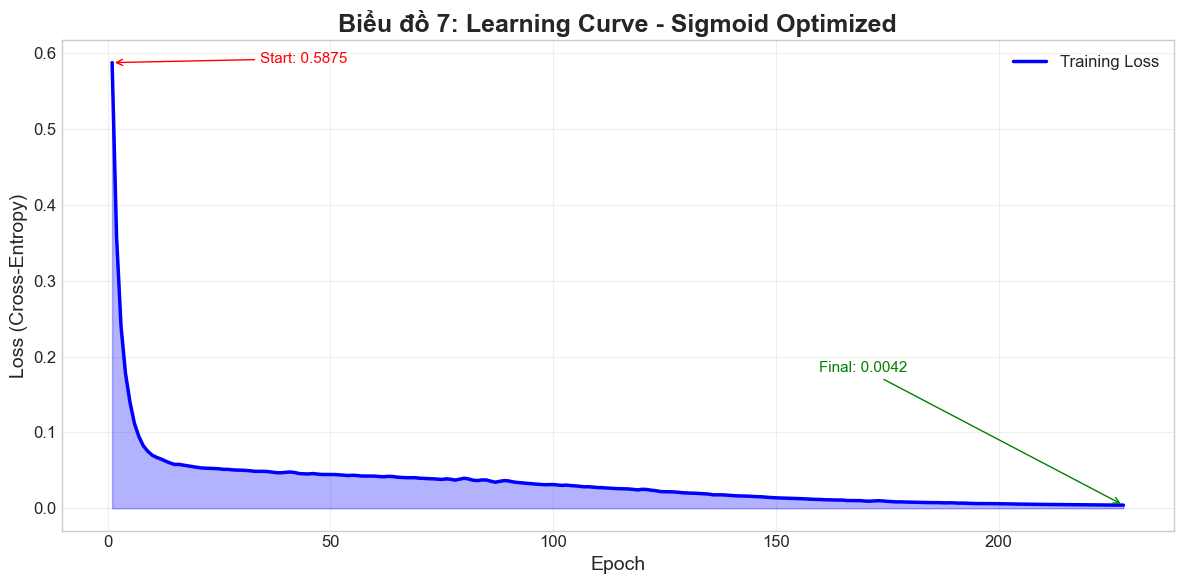

Đã lưu: reports/07_best_model_learning_curve.png


In [49]:
# Biểu đồ 7: Learning Curve chi tiết của model tốt nhất
fig, ax = plt.subplots(figsize=(12, 6))

loss_curve = best_result['loss_curve']
epochs = range(1, len(loss_curve) + 1)

ax.plot(epochs, loss_curve, 'b-', linewidth=2.5, label='Training Loss')
ax.fill_between(epochs, loss_curve, alpha=0.3, color='blue')

ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('Loss (Cross-Entropy)', fontsize=14)
ax.set_title(f'Biểu đồ 7: Learning Curve - {best_model_name.split(": ")[1]}', 
             fontsize=18, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Annotate
ax.annotate(f'Start: {loss_curve[0]:.4f}', xy=(1, loss_curve[0]),
            xytext=(len(loss_curve)*0.15, loss_curve[0]), fontsize=11, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))
ax.annotate(f'Final: {loss_curve[-1]:.4f}', xy=(len(loss_curve), loss_curve[-1]),
            xytext=(len(loss_curve)*0.7, loss_curve[-1] + (loss_curve[0]-loss_curve[-1])*0.3),
            fontsize=11, color='green', arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.savefig('../reports/07_best_model_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("Đã lưu: reports/07_best_model_learning_curve.png")

In [50]:
# Classification Report chi tiết
print("\nCLASSIFICATION REPORT - MODEL TỐT NHẤT:")
print("=" * 60)
print(classification_report(y_test, best_result['y_pred'], target_names=LABEL_NAMES))


CLASSIFICATION REPORT - MODEL TỐT NHẤT:
               precision    recall  f1-score   support

Malignant (M)       0.93      0.98      0.95        42
   Benign (B)       0.99      0.96      0.97        72

     accuracy                           0.96       114
    macro avg       0.96      0.97      0.96       114
 weighted avg       0.97      0.96      0.97       114



## 9. Lưu Model tốt nhất

In [51]:
import pickle

# Lưu model tốt nhất
best_model = trained_models[best_model_name]
model_path = '../models/best_mlp_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f"Model tốt nhất đã lưu tại: {model_path}")

# Lưu scaler
scaler_path = '../models/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler đã lưu tại: {scaler_path}")

# Lưu bảng so sánh
comparison_df.to_csv('../reports/model_comparison.csv', index=False)
print(f"Bảng so sánh đã lưu tại: reports/model_comparison.csv")

Model tốt nhất đã lưu tại: ../models/best_mlp_model.pkl
Scaler đã lưu tại: ../models/scaler.pkl
Bảng so sánh đã lưu tại: reports/model_comparison.csv


## 10. Kết luận

---

### Tóm tắt kết quả so sánh

In [52]:
# Tổng kết
print("=" * 80)
print("                    TỔNG KẾT DỰ ÁN MLP WDBC")
print("=" * 80)

print("\n[1] THÔNG TIN DATASET:")
print(f"    - Tổng số mẫu: 569 (Train: {X_train.shape[0]}, Test: {X_test.shape[0]})")
print(f"    - Số features: 30")
print(f"    - Classes: Malignant (ác tính) vs Benign (lành tính)")

print("\n[2] SO SÁNH 3 CẤU HÌNH:")
print("    +" + "-"*75 + "+")
print(f"    | {'Model':<25} | {'Accuracy':>10} | {'F1-Score':>10} | {'ROC-AUC':>10} |")
print("    +" + "-"*75 + "+")
for name, res in results.items():
    short = name.split(': ')[1]
    print(f"    | {short:<25} | {res['accuracy']:>10.4f} | {res['f1']:>10.4f} | {res['roc_auc']:>10.4f} |")
print("    +" + "-"*75 + "+")

print("\n[3] PHÂN TÍCH:")
print("    - Sigmoid Baseline (2 layers, lr=0.001): Gặp vấn đề Vanishing Gradient")
print("      -> Gradient quá nhỏ (0.25^2 = 6.25%), model học chậm/không học được")
print("    - Sigmoid Optimized (1 layer, lr=0.01): Cải thiện bằng cách giảm layers")
print("      -> Ít vanishing gradient hơn, learning rate cao giúp cập nhật nhanh")
print("    - ReLU (2 layers): Không có vanishing gradient")
print("      -> Đạo hàm = 1 (khi z > 0), gradient được truyền nguyên vẹn")

print(f"\n[4] KẾT LUẬN:")
print(f"    Model tốt nhất: {best_model_name.split(': ')[1]}")
print(f"    - Accuracy: {best_result['accuracy']:.4f} ({best_result['accuracy']*100:.2f}%)")
print(f"    - ROC-AUC: {best_result['roc_auc']:.4f}")

print("\n[5] BIỂU ĐỒ ĐÃ TẠO:")
print("    1. Phân bố lớp (Class Distribution)")
print("    2. Ma trận tương quan (Correlation Heatmap)")
print("    3. So sánh Learning Curves của 3 Models")
print("    4. So sánh Metrics của 3 Models")
print("    5. Confusion Matrices của 3 Models")
print("    6. ROC Curves của 3 Models")
print("    7. Learning Curve chi tiết của Model tốt nhất")

print("\n" + "=" * 80)
print("                    HOÀN THÀNH DỰ ÁN!")
print("=" * 80)

                    TỔNG KẾT DỰ ÁN MLP WDBC

[1] THÔNG TIN DATASET:
    - Tổng số mẫu: 569 (Train: 455, Test: 114)
    - Số features: 30
    - Classes: Malignant (ác tính) vs Benign (lành tính)

[2] SO SÁNH 3 CẤU HÌNH:
    +---------------------------------------------------------------------------+
    | Model                     |   Accuracy |   F1-Score |    ROC-AUC |
    +---------------------------------------------------------------------------+
    | Sigmoid Baseline          |     0.9561 |     0.9535 |     0.9960 |
    | Sigmoid Optimized         |     0.9649 |     0.9627 |     0.9924 |
    | ReLU                      |     0.9649 |     0.9627 |     0.9937 |
    +---------------------------------------------------------------------------+

[3] PHÂN TÍCH:
    - Sigmoid Baseline (2 layers, lr=0.001): Gặp vấn đề Vanishing Gradient
      -> Gradient quá nhỏ (0.25^2 = 6.25%), model học chậm/không học được
    - Sigmoid Optimized (1 layer, lr=0.01): Cải thiện bằng cách giảm layers
  

---

### Bảng tóm tắt công thức (đồng bộ Báo cáo ↔ Code)

| Thành phần | Công thức | Implementation |
|------------|-----------|----------------|
| **Chuẩn hóa Z-Score** | $z = \frac{x - \mu}{\sigma}$ | `StandardScaler()` |
| **Sigmoid** | $g(z) = \frac{1}{1+e^{-z}}$ | `activation='logistic'` |
| **ReLU** | $g(z) = \max(0, z)$ | `activation='relu'` |
| **Softmax (Output)** | $g(z_j) = \frac{e^{z_j}}{\sum_k e^{z_k}}$ | sklearn tự động |
| **Cross-Entropy Loss** | $L = -\sum_j y_j \log(\hat{y}_j)$ | sklearn mặc định |

### Khuyến nghị

- **Nếu phải dùng Sigmoid** (theo yêu cầu lý thuyết): Sử dụng **1 hidden layer** với **learning rate cao** (0.01-0.1)
- **Trong thực tế**: Sử dụng **ReLU** để tránh vanishing gradient và đạt hiệu suất tốt hơn

---